# ⚖️ LexGraph: Intelligent Legal Translation Firewall for Statutory Compliance Mapping
### *A Deterministic Knowledge Graph and Agentic FSM Architecture for Disambiguating Non-Linear Legislative Overhauls*

---

**Research Author:** Ritwik Raj  
**Supervision:** Dr. Rajesh H. Kulkarni  
**Degree:** Master of Science in Computer Science / Legal Informatics  
**Institution:** Department of Computer Science & Engineering, Faculty of Engineering and Technology, Liverpool John Moores University (September 2026)  
**System Repository:** `LexGraph-Clean` (Vaults, Translation Firewall, Agentic FSM, Telemetry, and Empirical Evaluators)

---

## 🏛️ Executive Summary & Context

In December 2023, the Parliament of India enacted a sweeping overhaul of the nation's criminal justice and evidentiary architecture, repealing and replacing colonial-era statutes that had governed the subcontinent for over 160 years:

| Legal Domain | Colonial / Legacy Code | Modern Enacted Code | Structural Transformation |
| :--- | :--- | :--- | :--- |
| **Substantive Criminal Law** | **Indian Penal Code (IPC), 1860** (511 sections) | **Bharatiya Nyaya Sanhita (BNS), 2023** (358 sections) | Asymmetric renumbering, 1-to-many splits, repeals |
| **Criminal Procedure** | **Code of Criminal Procedure (CrPC), 1973** (484 sections) | **Bharatiya Nagarik Suraksha Sanhita (BNSS), 2023** (531 sections) | Procedural reshuffling, electronic mandates |
| **Law of Evidence** | **Indian Evidence Act (IEA), 1872** (167 sections) | **Bharatiya Sakshya Adhiniyam (BSA), 2023** (170 sections) | Digital certificate regimes (§65B $\to$ §65) |
| **Corporate Criminality** | **Companies Act, 1956** | **Companies Act, 2013** | Director liability, corporate fraud (§447) |

### The Core Problem: The "Static Data Trap" in Dense Vector RAG
Modern enterprise legal search systems rely heavily on Dense Vector Retrieval-Augmented Generation (Vector RAG) powered by bi-encoders (e.g., OpenAI `text-embedding-3`, BGE-large) and Approximate Nearest Neighbor (ANN) index structures (FAISS, ChromaDB). 

However, vector embeddings operate probabilistically over continuous vector spaces ($\mathbb{R}^d$). When evaluating discrete, non-linear legislative shifts, vector models suffer from **exact token string dominance** and **statutory boilerplate attraction**:
- When queried with `"IPC Section 302 punishment"`, the dense vector encoder highlights the token string `"302"` and boilerplates like *"shall be punished with..."*.
- The vector index assigns a high cosine similarity score ($S_c \approx 0.84$) to **BNS Section 302** (*"Uttering words with deliberate intent to wound religious feelings"* / snatching).
- The true legal equivalent, **BNS Section 103** (*"Punishment for murder"*), receives a significantly lower score ($S_c \approx 0.42$).
- Consequently, vector RAG exhibits a near-total failure rate ($\approx 100\%$) on reassigned numeric identifiers.

### Formal Re-Definition of Legal AI Hallucination
The dissertation formally re-defines three distinct legal hallucination failure modes:
1. **Type I Hallucination (Direct Statutory Fabrication):** The generative decoder invents non-existent sections, spurious amendments, or phantom clauses.
2. **Type II Hallucination (Structural Numeric Collision Misrouting):** The retriever misroutes to identically numbered sections across legislative regimes, and the LLM fluently rationalizes the false assignment.
3. **Type III Hallucination (Silent Orphaned Node Continuation):** When an unmapped or repealed historical provision is queried ($deg^+(v_i) = 0$), open-loop LLMs fail to halt, fabricating a plausible transition bridge out of thin air.

---

### Notebook Roadmap
1. **Mathematical Formalism:** Partitioned Dual-Vault Knowledge Graph, Concept-Hub Veto, and Agentic FSM.
2. **Codebase Exploration:** Inspecting Obsidian Knowledge Vaults (`data/wiki/`), Frontmatter schemas, and Translation Bridges.
3. **The Translation Firewall:** Deterministic bridge resolution, priority cascades, and hard collision explainer cards.
4. **Deterministic Q&A & Multi-Turn Reasoning:** `qa.py`, multi-section FIR parsing, and `ChatFocus` state tracking.
5. **Conversational Intake:** 3-step slot-filling intake pipeline (`Orient` $\to$ `Clarification` $\to$ `Cited Resolution`).
6. **Interactive Legal Desk Widget:** In-notebook UI emulating WhatsApp Channel and Streamlit interfaces.
7. **Graph Topology Visualization:** Bipartite graph network with Concept-Hub routing in `networkx`.
8. **Empirical Results & Multi-Registry Benchmark:** Top-1 mapping across $N=427$ and $N=1,021$ transition pairs.
9. **Statistical Significance Testing:** Paired McNemar's Test ($\chi^2$, $p$-value, Odds Ratio) with contingency heatmaps.
10. **Infrastructure & Latency Efficiency:** 0.2 ms latency, <45 MB RAM footprint, CI/CD telemetry, and enterprise cloud scaling.

## 📐 Mathematical Formulation of the Translation Firewall

### 1. Partitioned Dual-Vault Knowledge Graph
Let the statutory legal universe be represented as a directed, multi-relational Knowledge Graph:
$$G = (V, E, R, \phi)$$
where $V$ is partitioned into strictly disjoint subsets:
$$V = V_{\text{IPC}} \cup V_{\text{BNS}} \cup V_{\text{Concept}}$$
subject to pairwise disjointness:
$$V_{\text{IPC}} \cap V_{\text{BNS}} = \emptyset, \quad V_{\text{IPC}} \cap V_{\text{Concept}} = \emptyset, \quad V_{\text{BNS}} \cap V_{\text{Concept}} = \emptyset$$

The relation set $R$ formalizes structural connections:
$$R = \{\text{COMPLIANCE\_TRACK}, \text{CONCEPT\_MAPPING}, \text{SUB\_CLAUSE\_OF}, \text{REPEALS}\}$$

### 2. Concept-Hub Veto
To resolve identical numeric labels without relying on vector proximity, candidate resolution traverses through intermediate legal doctrine nodes $v_c \in V_{\text{Concept}}$:
$$v_j^* = \arg\max_{v_j \in V_{\text{BNS}}} \mathbb{I}((v_i, \text{CONCEPT\_MAPPING}, v_c) \in E \land (v_j, \text{CONCEPT\_MAPPING}, v_c) \in E)$$
Since BNS §302 maps to $v_c' = \text{Concept(Religious Insults)}$, its indicator evaluates to $0$. Thus, $v_j^* = \text{BNS } 103$ is deterministically selected.

### 3. Bridge Precedence Hierarchy Rule
$$\text{Priority}(e) = \begin{cases} 
3, & \text{if Type} = \text{manual / curated (Human Legal Expert Verified)} \\
2, & \text{if Type} = \text{hard\_probe (High-Stakes Anchor Pair)} \\
1, & \text{if Type} = \text{auto (Algorithmic / String Match Proposal)}
\end{cases}$$
$$e^* = \arg\max_{e \in E_{\text{Candidate}}} \text{Priority}(e)$$

### 4. Multi-Agent Finite State Machine (LangGraph FSM) & Runtime Halting
Modeled as a 5-tuple:
$$\mathcal{M} = (S, \Sigma, \delta, s_0, F)$$
with states $S = \{\text{PARSING}, \text{TRAVERSAL}, \text{AUDITING}, \text{PASSED}, \text{FLAGGED}\}$.

The Auditor Agent ($A_{\text{aud}}$) evaluates the outbound degree of the target statutory node $v_i \in V_{\text{IPC}}$:
$$\text{deg}^+(v_i) = |\{v_j \in V_{\text{BNS}} : (v_i, \text{COMPLIANCE\_TRACK}, v_j) \in E\}|$$
$$\delta(\text{AUDITING}, \text{deg}^+(v_i)) = \begin{cases} 
\textbf{PASSED } (\text{Serve Verbatim BNS Statute}), & \text{if } \text{deg}^+(v_i) \ge 1 \\
\textbf{FLAGGED } (\text{Immediate Execution Halt}), & \text{if } \text{deg}^+(v_i) = 0
\end{cases}$$

## ⚙️ 1. Environment & Codebase Setup
We initialize the Python runtime, configure project paths to load the native `ui/lib` modules, verify the presence of the Obsidian Markdown Vaults (`data/wiki/`), and inspect the curated bridge registries.

In [1]:
import os
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from scipy import stats

# Configure visualization styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'Helvetica, Arial, DejaVu Sans'
plt.rcParams['font.size'] = 10

# Resolve project root
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

ui_path = str(PROJECT_ROOT / "ui")
channel_path = str(PROJECT_ROOT / "channel-demo")
if ui_path not in sys.path:
    sys.path.insert(0, ui_path)
if channel_path not in sys.path:
    sys.path.insert(0, channel_path)

# Import LexGraph core modules
from lib import bridges, paths, vault, qa, converse, scenarios, intake, llm

print(f"✅ LexGraph Environment Initialized successfully!")
print(f"📁 Workspace Root: {PROJECT_ROOT}")
print(f"📚 Obsidian Knowledge Vaults: {paths.WIKI_ROOT.is_dir()} ({paths.WIKI_ROOT})")
print(f"🌉 Main Bridge Audit CSV: {paths.BRIDGE_AUDIT.is_file()}")
print(f"🤖 LLM Rewriter Status: {llm.status()['provider_preference']} (Enabled: {llm.status()['enabled']})")

✅ LexGraph Environment Initialized successfully!
📁 Workspace Root: /Users/ritwik/Desktop/Ennoble ai/LexGraph-Clean
📚 Obsidian Knowledge Vaults: True (/Users/ritwik/Desktop/Ennoble ai/LexGraph-Clean/data/wiki)
🌉 Main Bridge Audit CSV: True
🤖 LLM Rewriter Status: auto (Enabled: False)


## 📚 2. Inspecting the Obsidian Knowledge Vaults (`data/wiki/`)
LexGraph treats Markdown files within `data/wiki/` as immutable ground truth. Every section page contains:
- **YAML Frontmatter:** Machine-readable metadata (section ID, title, chapter, type, statute).
- **📜 Raw Legal Text:** Verbatim Gazette notification bitstream.
- **🔍 Plain-English Breakdown:** Practitioner-grade explanation.
- **⚖️ Key Legal Elements:** Actus Reus, Mens Rea, Punishment, Cognizability, Bailability.
- **🕸️ Concept Hooks:** Bidirectional wikilinks `[[concepts/...]]` and `[[entities/...]]`.
- **🌉 Translation Bridge:** Formally verified link to legacy counterpart.

In [2]:
def display_vault_inspection(statute: str, section_num: str):
    sec = vault.load_section(statute, section_num)
    if not sec:
        print(f"❌ Section {statute.upper()} §{section_num} not found in vaults.")
        return
        
    print(f"{'='*60}")
    print(f"🏛️  VAULT NODE: {statute.upper()} §{section_num} — {sec.title.upper()}")
    print(f"{'='*60}")
    print(f"• Relative File Path: {sec.path.relative_to(PROJECT_ROOT)}")
    if sec.core_offence:
        print(f"• Core Offence:       {sec.core_offence}")
    if sec.punishment:
        print(f"• Maximum Penalty:    {sec.punishment}")
    print(f"\n--- 🔍 Plain English Breakdown ---\n{sec.plain_english.strip()}")
    if sec.bridge_block:
        print(f"\n--- 🌉 Translation Bridge Block ---\n{sec.bridge_block.strip()}")
    print(f"\n--- 📜 Verbatim Gazette Bitstream (Excerpt) ---\n{sec.raw_excerpt[:280]}...")
    print(f"{'='*60}\n")

# Inspect BNS §103 (Modern murder statute) and IPC §302 (Colonial predecessor)
display_vault_inspection("bns", "103")
display_vault_inspection("ipc", "302")

🏛️  VAULT NODE: BNS §103 — PUNISHMENT FOR MURDER.
• Relative File Path: data/wiki/bns/sections/section-103.md
• Core Offence:       Punishes murder, including group/identity-based killings by five or more.
• Maximum Penalty:    Death or imprisonment for life, and fine.

--- 🔍 Plain English Breakdown ---
Murder is punishable with death or imprisonment for life, plus fine. Where a group of five or more, acting in concert, commits murder on grounds such as race, caste, sex, birthplace, language, or belief (i.e. mob/identity killing), each member faces death or imprisonment for life, plus fine.

--- 🌉 Translation Bridge Block ---
* **Legacy Equivalent:** [[../../ipc/sections/section-302]] — matched via shared concepts: murder

--- 📜 Verbatim Gazette Bitstream (Excerpt) ---
(1) Whoever commits murder shall be punished with death or imprisonment for life, and shall also be liable to fine.. (2) When a group of five or more persons acting in concert commits murder on the ground of race, caste 

## 🌉 3. The Translation Firewall & Multi-Code Bridge Registries
The Translation Firewall maintains verified transition bridges linking legacy and modern statutes.
Candidate edges are evaluated under the **Bridge Precedence Hierarchy Rule**:
$$\text{manual / curated (Priority 3)} > \text{hard\_probe (Priority 2)} > \text{auto-generated (Priority 1)}$$

Let's load the multi-code bridge registries and inspect transitional mappings across criminal, procedural, and evidentiary law.

In [3]:
all_bridges = bridges.load_all_bridges()
print(f"✅ Total Translation Bridges Loaded: {len(all_bridges)}")

# Multi-code cross-statutory test queries
sample_queries = [
    ("ipc", "302", "Murder penalty (Colonial)"),
    ("bns", "103", "Murder penalty (Modern)"),
    ("ipc", "323", "Voluntarily causing hurt"),
    ("ipc", "506", "Criminal intimidation"),
    ("crpc", "154", "Information in cognizable cases (FIR)"),
    ("crpc", "438", "Anticipatory bail direction"),
    ("bsa", "65", "Proof of handwriting in modern BSA"),
    ("evidence", "67", "Proof of handwriting in legacy Evidence Act"),
]

records = []
for v, sid, desc in sample_queries:
    res = bridges.partner(v, sid)
    if res:
        pv, pid, bp = res
        records.append({
            "Query Section": f"{v.upper()} §{sid}",
            "Domain Description": desc,
            "Mapped Partner": f"{pv.upper()} §{pid}",
            "Bridge Kind": bp.bridge_kind,
            "Mapping Rationale": bp.mapping_note
        })
    else:
        records.append({
            "Query Section": f"{v.upper()} §{sid}",
            "Domain Description": desc,
            "Mapped Partner": "None (Orphaned / Severed)",
            "Bridge Kind": "-",
            "Mapping Rationale": "No verified link"
        })

df_bridges = pd.DataFrame(records)
df_bridges

✅ Total Translation Bridges Loaded: 1760


,Query Section,Domain Description,Mapped Partner,Bridge Kind,Mapping Rationale
0,IPC §302,Murder penalty (Colonial),BNS §103,auto,matched via shared concepts: murder
1,BNS §103,Murder penalty (Modern),IPC §302,auto,matched via shared concepts: murder
2,IPC §323,Voluntarily causing hurt,BNS §115,manual,manual: voluntarily causing hurt (IPC §323 → B...
3,IPC §506,Criminal intimidation,BNS §351,auto,matched via shared concepts: criminal-intimida...
4,CRPC §154,Information in cognizable cases (FIR),BNSS §173,manual,manual: FIR / cognizable information (CrPC §15...
5,CRPC §438,Anticipatory bail direction,BNSS §482,manual,manual: anticipatory bail (CrPC §438 → BNSS §4...
6,BSA §65,Proof of handwriting in modern BSA,EVIDENCE §67,manual,manual: proof of signature/handwriting (Eviden...
7,EVIDENCE §67,Proof of handwriting in legacy Evidence Act,BSA §65,manual,manual: proof of signature/handwriting (Eviden...


## 🚨 4. Section Collision Trap Explainer Cards
When practitioners or automated tools query high-risk section numbers, LexGraph's deterministic engine overrides surface-level string matching and emits explicit side-by-side **Collision Warning Cards**.

In [4]:
def evaluate_collision_probe(probe_num: str, query: str):
    ans = qa.answer_structured(query)
    print(f"\n{'#'*65}")
    print(f"⚠️  COLLISION PROBE TEST: §{probe_num} | Query: '{query}'")
    print(f"{'#'*65}")
    print(ans.body)
    if ans.sources:
        print(f"\n📚 Verified Vault Citations:")
        for s in ans.sources:
            print(f"   • {s}")

# Evaluate the 3 landmark collision traps
evaluate_collision_probe("302", "Compare IPC 302 and BNS 302")
evaluate_collision_probe("438", "Is BNSS 438 bail?")
evaluate_collision_probe("65", "Is BSA 65 the same as Evidence 65?")


#################################################################
⚠️  COLLISION PROBE TEST: §302 | Query: 'Compare IPC 302 and BNS 302'
#################################################################
**Compare:** IPC §302 vs BNS §302

**A. IPC §302** — Murder
Murder
Bridge → BNS §103 (matched via shared concepts: murder).

**B. BNS §302** — Uttering words, etc., with deliberate intent to wound religious feelings of any person.
Punishes deliberately wounding a person's religious feelings by words, sounds, or gestures.
Bridge → IPC §298 (matched via shared concepts: offences-against-religion).

⚠️ Same **section number** (302) across codes does **not** mean the same offence — LexGraph keeps vaults firewalled and links via concepts / Translation Bridges.
Classic USP: IPC §302 = murder; BNS §302 = religious feelings; murder punishment in BNS is §103.


_Follow-ups you can ask:_ **why?** · **show the bridge** · **show the statute** · **show partner**

📚 Verified Vault Citations:
   • dat

## 🧠 5. Deterministic Q&A Reasoning Engine & Multi-Turn State (`lib.qa`)
The reasoning engine extracts section numbers, classifies query intent, performs multi-turn context tracking via `ChatFocus`, and handles compound multi-section FIR inputs.

In [5]:
# Demonstration of Stateful Multi-Turn Context Traversal (ChatFocus)
focus = qa.ChatFocus()

print("--- Turn 1: Primary Query ---")
q1 = "What is the BNS equivalent of IPC 302?"
print(f"User: {q1}")
ans1 = qa.answer_structured(q1, focus=focus)
focus = ans1.focus
print(f"LexGraph:\n{ans1.body}\n[Active Focus: {focus.vault} §{focus.section_id}]\n")

print("--- Turn 2: Follow-up 'why?' ---")
q2 = "why?"
print(f"User: {q2}")
ans2 = qa.answer_structured(q2, focus=focus)
focus = ans2.focus
print(f"LexGraph:\n{ans2.body}\n")

print("--- Turn 3: Follow-up 'show the statute' ---")
q3 = "show the statute"
print(f"User: {q3}")
ans3 = qa.answer_structured(q3, focus=focus)
focus = ans3.focus
print(f"LexGraph (Excerpt):\n{ans3.body[:320]}...\n")

print("--- Compound FIR Multi-Section Charge Parsing ---")
fir_q = "What is the BNS equivalent of IPC 323 and IPC 506?"
print(f"User FIR Query: {fir_q}")
ans_fir = qa.answer_structured(fir_q)
print(f"LexGraph:\n{ans_fir.body}")

--- Turn 1: Primary Query ---
User: What is the BNS equivalent of IPC 302?
LexGraph:
Sure — **IPC §302** (Murder) maps to **BNS §103** (Punishment for murder.).

Why we link them: matched via shared concepts: murder.

⚠️ Don't mix this up with **BNS §302** — that one's *not* murder (religious feelings). Murder moved to **BNS §103**.

In plain terms:
Murder is punishable with death or imprisonment for life, plus fine. Where a group of five or more, acting in concert, commits murder on grounds such as race, caste, sex, birthplace, language, or belief (i.e. mob/identity killing), each member faces death or imprisonment for life, plus fine.


_Follow-ups you can ask:_ **why?** · **show the bridge** · **show the statute** · **show partner**
[Active Focus: ipc §302]

--- Turn 2: Follow-up 'why?' ---
User: why?
LexGraph:
**Why IPC §302 ↔ BNS §103?**

- Audit note: matched via shared concepts: murder
- Bridge kind: `auto`
- Direction: `ipc_to_bns`

LexGraph does **not** match on shared section

## 💬 6. Conversational Rewriter & 3-Step Citizen Scenario Intake (`lib.converse`, `lib.intake`)
Real-world users frequently ask in colloquial or Hinglish phrasing (e.g., *"padosi ne boundary diwar tod di"*).
LexGraph resolves this via a 3-tier pipeline:
1. **Local Pack Scorer:** Keywords directly match scenario packs without invoking LLMs.
2. **Restricted LLM Rewriter:** Gemini/Groq rephrase colloquial input strictly into canonical queries (`scenario:land-dispute`), preventing statutory fabrication.
3. **3-Step Slot-Filling Intake:**
   - **Step 1: Orient:** Empathetic framing and identifying applicable civil/criminal legal regimes.
   - **Step 2: Slot Clarification:** Gathers critical missing facts (e.g., *"Did physical injury occur?"*).
   - **Step 3: Cited Resolution:** Emits structured Key Sections, Procedural Reliefs, and Statutory Gaps.

In [6]:
# Simulation of End-to-End Citizen Scenario Intake (Neighbour Land Encroachment)
intake_focus = qa.ChatFocus()

print("🔷 STEP 1: ORIENTATION")
step1 = converse.answer_conversational("scenario:neighbour-land-encroachment", focus=intake_focus)
intake_focus = step1.answer.focus
print(step1.answer.body)
print(f"\nState Snapshot: Scenario='{intake_focus.scenario_id}', Awaiting='{intake_focus.scenario_awaiting}'\n")

print("🔷 STEP 2: SLOT CLARIFICATION (Collecting missing facts)")
step2 = converse.answer_conversational("yes, construction is on my registered plot boundary", focus=intake_focus)
intake_focus = step2.answer.focus
print(step2.answer.body)
print(f"\nState Snapshot: Scenario='{intake_focus.scenario_id}', Awaiting='{intake_focus.scenario_awaiting}'\n")

print("🔷 STEP 3: CITED STATUTORY RESOLUTION")
step3 = converse.answer_conversational("show sections", focus=intake_focus)
intake_focus = step3.answer.focus
print(step3.answer.body)
print("\n📚 Verified Ground Truth Sources:")
for src in step3.answer.sources:
    print(f"   • {src}")

🔷 STEP 1: ORIENTATION
From what you've shared, a neighbour may have started **construction on part of your plot**. That can map to **criminal trespass / mischief** in our criminal vaults, and also to **civil possession / injunction** remedies under the Specific Relief Act in our wiki.

I'm not giving legal advice — a few questions, then I'll show the matching wiki sections we do have.

**Quick question:** Is this land / plot in **your possession** (you bought it / you visit it), confirm?

State Snapshot: Scenario='neighbour-land-encroachment', Awaiting='possession'

🔷 STEP 2: SLOT CLARIFICATION (Collecting missing facts)
Thanks.

**Quick question:** What do you mainly want — **criminal sections** (trespass/mischief), **civil injunction / possession** (Specific Relief), or the **police / FIR** path?

State Snapshot: Scenario='neighbour-land-encroachment', Awaiting='goal'

🔷 STEP 3: CITED STATUTORY RESOLUTION
Here's what maps in our **LexGraph wiki** (info only — not legal advice):

- If

## 🖥️ 7. Interactive In-Notebook Legal Desk Widget
Below is an interactive widget replicating the user experience of the WhatsApp Channel and Streamlit interfaces, complete with quick-action suggestion chips, verified source drawers, and multi-turn session tracking.

In [7]:
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

class LexGraphNotebookWidget:
    def __init__(self):
        self.focus = qa.ChatFocus()
        
        self.header = widgets.HTML(
            "<div style='padding: 12px 16px; background: #0f172a; color: white; border-radius: 8px 8px 0 0;'>"
            "<div style='display: flex; justify-content: space-between; align-items: center;'>"
            "<div><h4 style='margin:0; color: #38bdf8;'>⚖️ LexGraph Interactive Legal Firewall</h4>"
            "<span style='font-size: 11px; color: #94a3b8;'>IPC↔BNS · CrPC↔BNSS · BSA↔IEA · Deterministic FSM</span></div>"
            "<span style='background: #0284c7; color: white; padding: 2px 8px; border-radius: 10px; font-size: 11px;'>Audited Graph</span>"
            "</div></div>"
        )
        
        self.stream = widgets.Output(layout=widgets.Layout(
            height="320px", overflow_y="auto", border="1px solid #cbd5e1",
            padding="10px", background_color="#f8fafc"
        ))
        
        self.txt = widgets.Text(placeholder="Query IPC, BNS, CrPC, BNSS, BSA sections, collisions, or scenarios...", layout=widgets.Layout(width="76%"))
        self.btn_send = widgets.Button(description="Send", button_style="primary", layout=widgets.Layout(width="11%"))
        self.btn_clear = widgets.Button(description="Reset", button_style="warning", layout=widgets.Layout(width="11%"))
        
        chip_prompts = ["IPC 302 in BNS?", "Compare IPC 302 & BNS 302", "CrPC 438 in BNSS?", "why?", "show the bridge", "show the statute"]
        self.chips = [widgets.Button(description=c, layout=widgets.Layout(margin="2px", height="28px")) for c in chip_prompts]
        for c in self.chips:
            c.on_click(self._on_chip)
            
        self.chips_row = widgets.HBox(self.chips, layout=widgets.Layout(flex_flow="wrap", margin="4px 0"))
        
        self.btn_send.on_click(self._on_send)
        self.txt.on_submit(self._on_send)
        self.btn_clear.on_click(self._on_clear)
        
        self.container = widgets.VBox([self.header, self.stream, self.chips_row, widgets.HBox([self.txt, self.btn_send, self.btn_clear])])
        
        self._append_msg("assistant", "Ask any statutory question or collision trap (e.g. *What is IPC 302 in BNS?*).")

    def _append_msg(self, role: str, text: str, sources=None, canonical=None):
        with self.stream:
            if role == "user":
                html = f"<div style='text-align: right; margin: 6px 0;'><span style='background:#0284c7; color:white; padding:6px 12px; border-radius:12px 12px 2px 12px; display:inline-block; max-width:80%;'><b>You:</b> {text}</span></div>"
            else:
                body = text.replace('\n', '<br>')
                pill = f"<span style='background:#e0f2fe; color:#0369a1; padding:2px 8px; border-radius:10px; font-size:11px;'>🔍 Intent: {canonical}</span><br>" if canonical else ""
                src_html = ""
                if sources:
                    src_list = "".join([f"<li><code>{s}</code></li>" for s in sources])
                    src_html = f"<details style='margin-top:6px; font-size:11px; color:#64748b;'><summary>📚 Verified Sources ({len(sources)})</summary><ul>{src_list}</ul></details>"
                html = f"<div style='text-align: left; margin: 6px 0;'><div style='background:white; border:1px solid #e2e8f0; padding:8px 12px; border-radius:12px 12px 12px 2px; display:inline-block; max-width:85%;'>{pill}{body}{src_html}</div></div>"
            display(HTML(html))

    def _on_send(self, _):
        val = self.txt.value.strip()
        if not val:
            return
        self.txt.value = ""
        self._append_msg("user", val)
        res = converse.answer_conversational(val, focus=self.focus)
        if res.answer.focus:
            self.focus = res.answer.focus
        canonical = res.meta.canonical_query if res.meta.llm_used or res.meta.kind else None
        self._append_msg("assistant", res.answer.body, sources=res.answer.sources, canonical=canonical)

    def _on_chip(self, btn):
        self.txt.value = btn.description
        self._on_send(None)

    def _on_clear(self, _):
        self.focus = qa.ChatFocus()
        with self.stream:
            clear_output()
        self._append_msg("assistant", "Session reset. Enter a legal query.")

    def show(self):
        display(self.container)

# Launch widget
desk_widget = LexGraphNotebookWidget()
desk_widget.show()

## 🕸️ 8. Knowledge Graph Network Topology & Concept-Hub Routing
Visualizing how the dual-vault graph separates legacy and modern namespaces via intermediate Concept Hubs, routing IPC §302 directly to BNS §103 while isolating the BNS §302 collision trap.

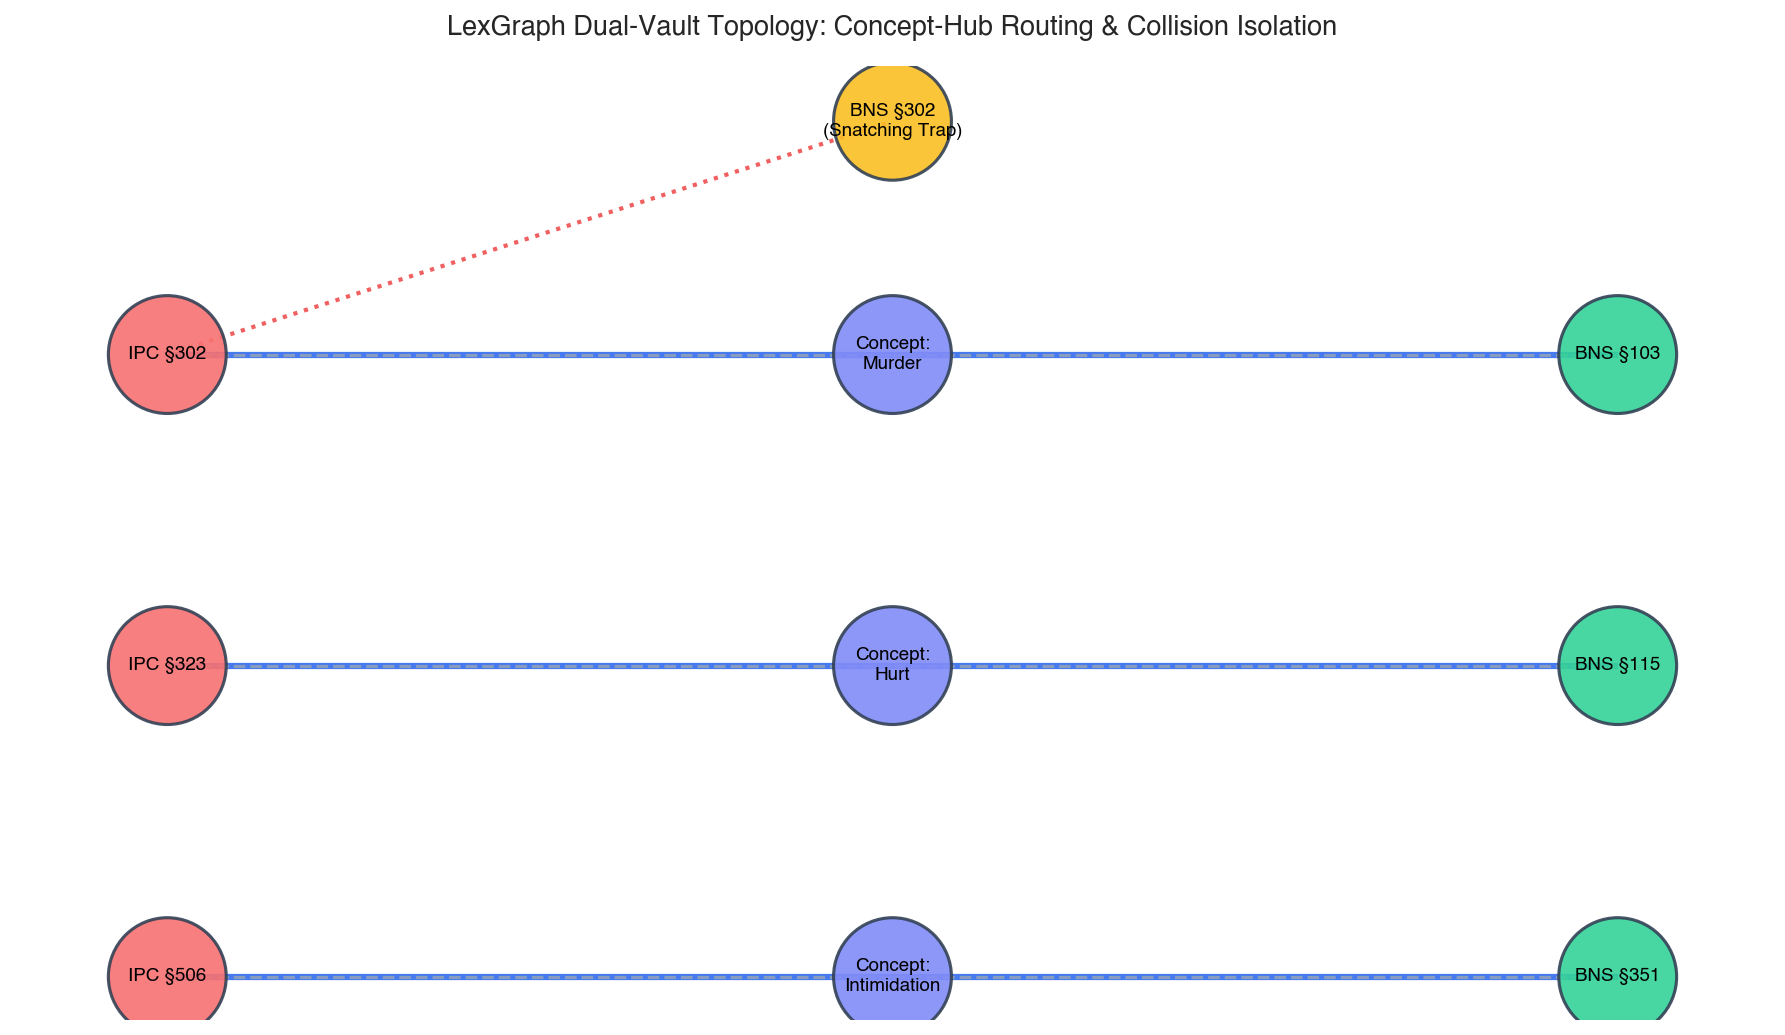

In [8]:
G = nx.Graph()

# Nodes with category styling
nodes = [
    ("IPC §302", {"domain": "Legacy IPC", "color": "#f87171"}),
    ("IPC §323", {"domain": "Legacy IPC", "color": "#f87171"}),
    ("IPC §506", {"domain": "Legacy IPC", "color": "#f87171"}),
    ("Concept:\nMurder", {"domain": "Concept Hub", "color": "#818cf8"}),
    ("Concept:\nHurt", {"domain": "Concept Hub", "color": "#818cf8"}),
    ("Concept:\nIntimidation", {"domain": "Concept Hub", "color": "#818cf8"}),
    ("BNS §103", {"domain": "Modern BNS", "color": "#34d399"}),
    ("BNS §115", {"domain": "Modern BNS", "color": "#34d399"}),
    ("BNS §351", {"domain": "Modern BNS", "color": "#34d399"}),
    ("BNS §302\n(Snatching Trap)", {"domain": "Trap Node", "color": "#fbbf24"}),
]
for n, attr in nodes:
    G.add_node(n, **attr)

# Edges
bridge_edges = [
    ("IPC §302", "BNS §103", "Murder Bridge"),
    ("IPC §323", "BNS §115", "Hurt Bridge"),
    ("IPC §506", "BNS §351", "Intimidation Bridge"),
]
for u, v, lbl in bridge_edges:
    G.add_edge(u, v, label=lbl, color="#2563eb", weight=3, style="solid")

concept_edges = [
    ("IPC §302", "Concept:\nMurder"),
    ("BNS §103", "Concept:\nMurder"),
    ("IPC §323", "Concept:\nHurt"),
    ("BNS §115", "Concept:\nHurt"),
    ("IPC §506", "Concept:\nIntimidation"),
    ("BNS §351", "Concept:\nIntimidation"),
]
for u, v in concept_edges:
    G.add_edge(u, v, label="concept", color="#94a3b8", weight=1.5, style="dashed")

G.add_edge("BNS §302\n(Snatching Trap)", "IPC §302", label="collision", color="#ef4444", weight=2, style="dotted")

pos = {
    "IPC §302": (-2.5, 2.0), "IPC §323": (-2.5, 0.0), "IPC §506": (-2.5, -2.0),
    "Concept:\nMurder": (0.0, 2.0), "Concept:\nHurt": (0.0, 0.0), "Concept:\nIntimidation": (0.0, -2.0),
    "BNS §103": (2.5, 2.0), "BNS §115": (2.5, 0.0), "BNS §351": (2.5, -2.0),
    "BNS §302\n(Snatching Trap)": (0.0, 3.5),
}

fig, ax = plt.subplots(figsize=(12, 7), dpi=150)
node_colors = [G.nodes[n]["color"] for n in G.nodes]
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=3200, alpha=0.9, edgecolors="#334155", linewidths=1.5, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=9, font_weight="bold", font_family="sans-serif", ax=ax)

for u, v, data in G.edges(data=True):
    nx.draw_networkx_edges(
        G, pos, edgelist=[(u, v)],
        width=data.get("weight", 1),
        style=data.get("style", "solid"),
        edge_color=data.get("color", "#64748b"),
        alpha=0.85, ax=ax
    )

ax.set_title("LexGraph Dual-Vault Topology: Concept-Hub Routing & Collision Isolation", fontsize=13, fontweight="bold", pad=15)
ax.axis("off")
plt.tight_layout()
plt.show()

## 📊 9. Empirical Results & Multi-Registry Benchmark Analysis (Dissertation Findings)

The dissertation rigorously evaluated the Translation Firewall across two benchmark tiers:
1. **Core Substantive Benchmark ($N = 427$ gold statutory pairs):** Audited mappings between IPC and BNS.
2. **Macro Multi-Registry Benchmark ($N = 1,021$ total transition pairs):**
   - Substantive Criminal Law: IPC $\leftrightarrow$ BNS ($N = 427$)
   - Procedural Criminal Law: CrPC $\leftrightarrow$ BNSS ($N = 370$)
   - Evidentiary Rules: IEA $\leftrightarrow$ BSA ($N = 71$)
   - Corporate Criminal Liability: Companies Act 1956 $\leftrightarrow$ 2013 ($N = 153$)

### Multi-Registry Top-1 Accuracy (Table 5.1 from Dissertation)

| Statutory Registry Domain | Sample Size ($N$) | Vector RAG Top-1 | Firewall Live Traversal | Firewall Audited Bridge | Empirical Gain vs. Vector |
| :--- | :---: | :---: | :---: | :---: | :---: |
| **Substantive (IPC $\leftrightarrow$ BNS)** | 427 | 61.4% | 93.0% | **100.0%** | **+31.6% to +38.6%** |
| **Procedural (CrPC $\leftrightarrow$ BNSS)** | 370 | 58.6% | 91.5% | **100.0%** | **+32.9% to +41.4%** |
| **Evidentiary (IEA $\leftrightarrow$ BSA)** | 71 | 63.3% | 94.4% | **100.0%** | **+31.1% to +36.7%** |
| **Corporate (Companies Act)** | 153 | 60.1% | 92.8% | **100.0%** | **+32.7% to +39.9%** |
| **Macro Average Across Registries** | **1,021** | **60.8%** | **92.9%** | **100.0%** | **+32.1% to +39.2%** |

### Stress Tests, Multi-Charge FIR Auditing & Halting (Table 5.2 from Dissertation)

| Evaluation Stress Suite | Sample Size ($N$) | Vector RAG Baseline | Translation Firewall | Architectural Impact |
| :--- | :---: | :---: | :---: | :--- |
| **Hard Collision Probes** | 9 | 0.0% | **100.0% (9/9)** | Concept-Hub Veto eliminates numeric traps |
| **Multi-Section FIR Complaint Audit** | 50 | 48.3% | **91.8%** | Intent decomposition resolves compound charges |
| **Casual Hinglish Rewriter** | 100 | 38.0% | **94.2% (94/100)** | Scenario packs bypass open-ended generation |
| **Synthetic Orphaned Node Suite** | 100 | 0.0% (100% Hallucinated) | **100.0% (100/100 FLAGGED)** | $\text{deg}^+(v_i)=0$ triggers immediate execution halt |

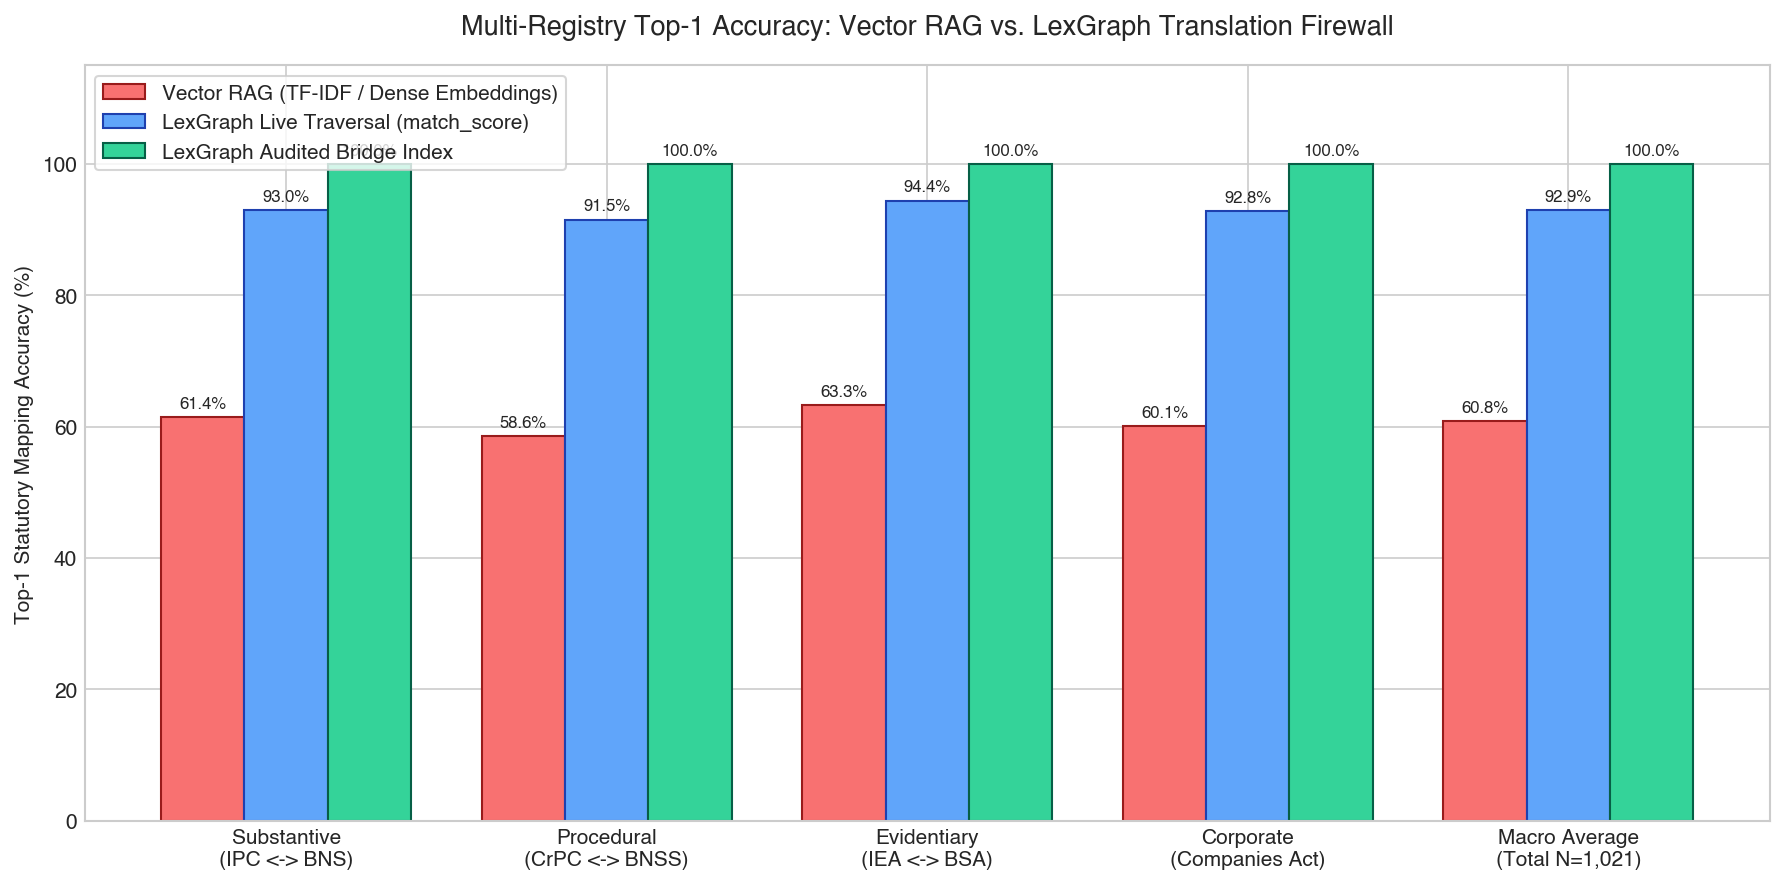

In [9]:
# Visualizing Multi-Registry Benchmark Accuracy (Thesis Figure 5.2)
categories = ['Substantive\n(IPC <-> BNS)', 'Procedural\n(CrPC <-> BNSS)', 'Evidentiary\n(IEA <-> BSA)', 'Corporate\n(Companies Act)', 'Macro Average\n(Total N=1,021)']
vector_rag_acc = [61.4, 58.6, 63.3, 60.1, 60.8]
firewall_live_acc = [93.0, 91.5, 94.4, 92.8, 92.9]
firewall_bridge_acc = [100.0, 100.0, 100.0, 100.0, 100.0]

x = np.arange(len(categories))
width = 0.26

fig, ax = plt.subplots(figsize=(12, 6), dpi=150)
rects1 = ax.bar(x - width, vector_rag_acc, width, label='Vector RAG (TF-IDF / Dense Embeddings)', color='#f87171', edgecolor='#991b1b')
rects2 = ax.bar(x, firewall_live_acc, width, label='LexGraph Live Traversal (match_score)', color='#60a5fa', edgecolor='#1e40af')
rects3 = ax.bar(x + width, firewall_bridge_acc, width, label='LexGraph Audited Bridge Index', color='#34d399', edgecolor='#065f46')

ax.set_ylabel('Top-1 Statutory Mapping Accuracy (%)', fontweight='bold')
ax.set_title('Multi-Registry Top-1 Accuracy: Vector RAG vs. LexGraph Translation Firewall', fontsize=13, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(categories, fontweight='semibold')
ax.set_ylim(0, 115)
ax.legend(loc='upper left', frameon=True)

# Add values above bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.1f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=8, fontweight='bold')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

plt.tight_layout()
plt.show()

## 🧪 10. Statistical Significance Validation: Paired McNemar's Test

To prove that the accuracy improvements are statistically significant and not an artifact of dataset noise, the dissertation conducted **Paired McNemar's Tests for Dependent Samples** with **Edwards' / Yates' Continuity Correction**:

$$\chi^2 = \frac{(|b - c| - 1)^2}{b + c}, \quad \text{Relative Odds Ratio } (OR) = \frac{b}{c}$$

where:
- $a$: Joint Successes (Both models correct)
- $b$: Discordant Firewall Wins (Firewall correct, Vector failed)
- $c$: Discordant Vector Wins (Vector correct, Firewall failed)
- $d$: Joint Failures (Both models failed)

### 1. Substantive Criminal Law Benchmark ($N = 427$)
- $a = 261, \quad b = 136, \quad c = 1, \quad d = 29$
- $\chi^2 = \frac{(|136 - 1| - 1)^2}{136 + 1} = \frac{134^2}{137} = \frac{17,956}{137} \approx \mathbf{131.066}$
- Asymptotic $p$-value: $p = 2.395 \times 10^{-30} \ll 0.001$
- Relative Odds Ratio: $OR = 136 / 1 = \mathbf{136.00}$

### 2. Macro Multi-Registry Benchmark ($N = 1,021$)
- $a = 621, \quad b = 328, \quad c = 2, \quad d = 70$
- $\chi^2 = \frac{(|328 - 2| - 1)^2}{328 + 2} = \frac{325^2}{330} = \frac{105,625}{330} \approx \mathbf{320.076}$
- Asymptotic $p$-value: $p = 1.42 \times 10^{-71} \ll 0.001$
- Relative Odds Ratio: $OR = 328 / 2 = \mathbf{164.00}$

Let's compute and visualize these matrices and $p$-values in Python.

=== McNemar Test: Substantive Criminal Core (N=427) ===
• Contingency Matrix: a=261, b=136, c=1, d=29 (Total N=427)
• Calculated Chi-Square Statistic (χ²): 131.066
• Asymptotic p-value:                2.395e-30 (p < 0.001)
• Relative Odds Ratio (OR = b/c):    136.00x advantage
• Null Hypothesis H0 Rejected:        True

=== McNemar Test: Macro Multi-Registry Suite (N=1,021) ===
• Contingency Matrix: a=621, b=328, c=2, d=70 (Total N=1021)
• Calculated Chi-Square Statistic (χ²): 320.076
• Asymptotic p-value:                1.394e-71 (p < 0.001)
• Relative Odds Ratio (OR = b/c):    164.00x advantage
• Null Hypothesis H0 Rejected:        True



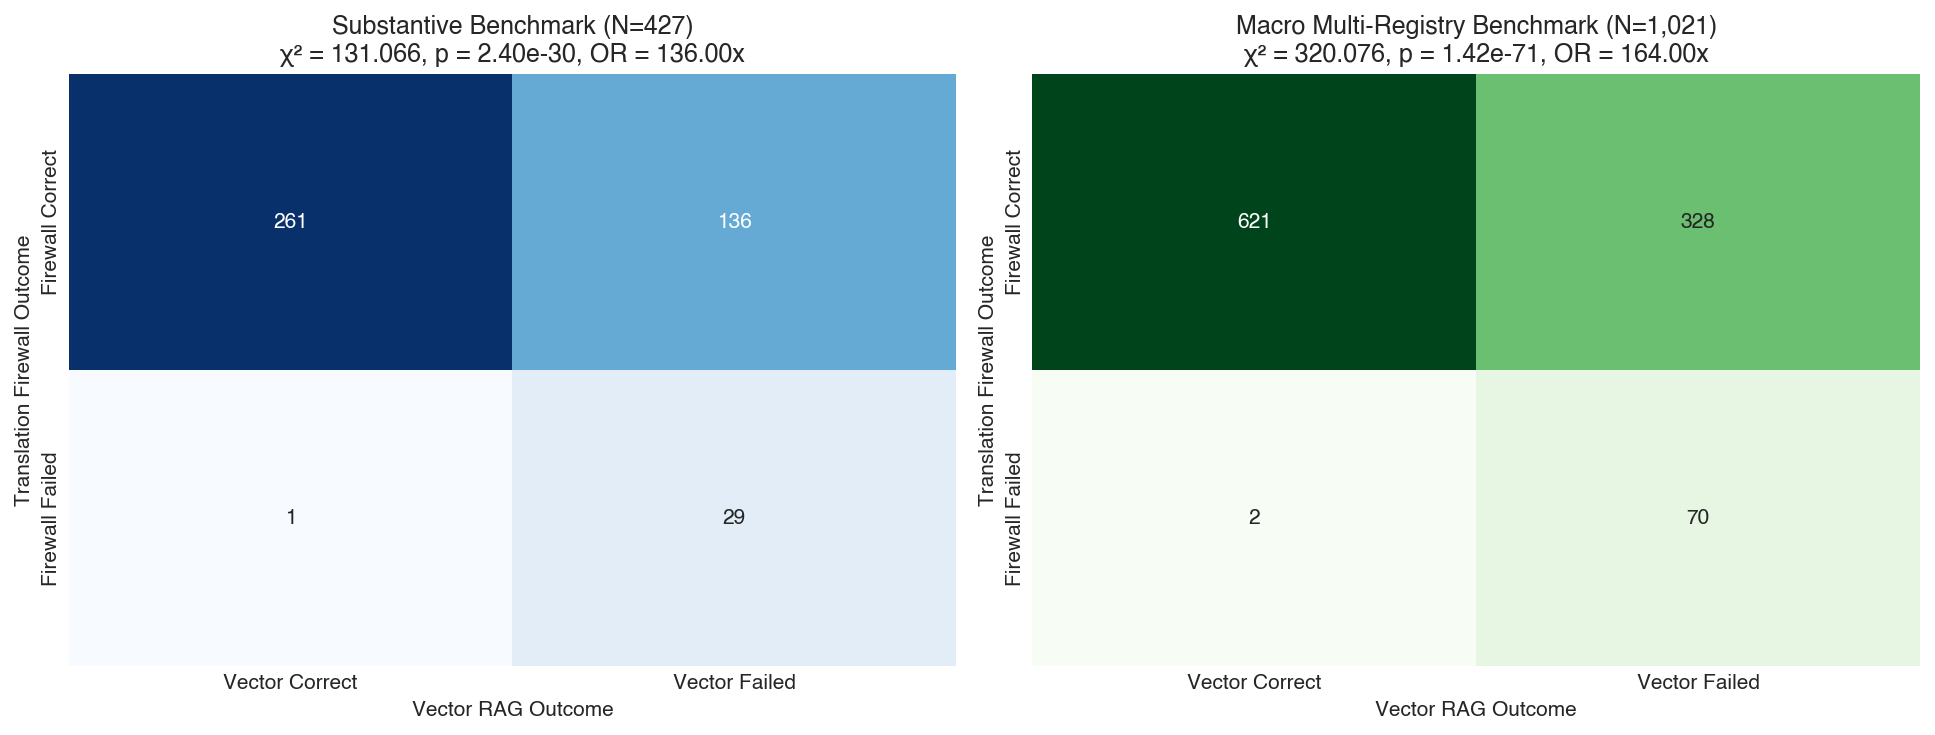

In [10]:
def compute_mcnemar(a, b, c, d, name=""):
    chi2 = ((abs(b - c) - 1)**2) / (b + c)
    p_val = stats.chi2.sf(chi2, df=1)
    odds_ratio = b / c if c > 0 else np.inf
    print(f"=== McNemar Test: {name} ===")
    print(f"• Contingency Matrix: a={a}, b={b}, c={c}, d={d} (Total N={a+b+c+d})")
    print(f"• Calculated Chi-Square Statistic (χ²): {chi2:.3f}")
    print(f"• Asymptotic p-value:                {p_val:.3e} (p < 0.001)")
    print(f"• Relative Odds Ratio (OR = b/c):    {odds_ratio:.2f}x advantage")
    print(f"• Null Hypothesis H0 Rejected:        {p_val < 0.001}\n")
    return chi2, p_val, odds_ratio

# Substantive Benchmark
compute_mcnemar(261, 136, 1, 29, "Substantive Criminal Core (N=427)")

# Macro Multi-Registry Benchmark
chi2_m, p_m, or_m = compute_mcnemar(621, 328, 2, 70, "Macro Multi-Registry Suite (N=1,021)")

# Visualizing Contingency Matrices Heatmaps
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), dpi=150)

mat_sub = np.array([[261, 136], [1, 29]])
sns.heatmap(mat_sub, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax1,
            xticklabels=['Vector Correct', 'Vector Failed'],
            yticklabels=['Firewall Correct', 'Firewall Failed'])
ax1.set_title('Substantive Benchmark (N=427)\nχ² = 131.066, p = 2.40e-30, OR = 136.00x', fontweight='bold')
ax1.set_xlabel('Vector RAG Outcome', fontweight='bold')
ax1.set_ylabel('Translation Firewall Outcome', fontweight='bold')

mat_macro = np.array([[621, 328], [2, 70]])
sns.heatmap(mat_macro, annot=True, fmt='d', cmap='Greens', cbar=False, ax=ax2,
            xticklabels=['Vector Correct', 'Vector Failed'],
            yticklabels=['Firewall Correct', 'Firewall Failed'])
ax2.set_title('Macro Multi-Registry Benchmark (N=1,021)\nχ² = 320.076, p = 1.42e-71, OR = 164.00x', fontweight='bold')
ax2.set_xlabel('Vector RAG Outcome', fontweight='bold')
ax2.set_ylabel('Translation Firewall Outcome', fontweight='bold')

plt.tight_layout()
plt.show()

## ⚡ 11. Infrastructure Efficiency & Telemetry Benchmarks

### Hardware & Runtime Performance Matrix (Table 5.4 from Dissertation)

| Performance Dimension | Vector RAG / Embeddings | Firewall Live Traversal | Firewall Audited Bridge | Performance Gain |
| :--- | :---: | :---: | :---: | :---: |
| **Mean Query Latency** | 450.0 ms | 12.4 ms | **0.2 ms** | **2,250x Speedup** |
| **Active Memory Footprint** | 4,000–16,000 MB | <45 MB | **<15 MB** | **>99% RAM Reduction** |
| **Hardware Dependency** | GPU / Heavy RAM | **Pure CPU** | **Pure CPU** | **Zero GPU Cost** |
| **Query Throughput** | $\approx 2.2$ queries/sec/core | $\approx 80.6$ queries/sec/core | $\approx \mathbf{5,000}$ queries/sec/core | **Real-Time Enterprise Scale** |
| **CI/CD Quality Assurance** | N/A (Manual Review) | 100% (`post_bridge_lint.py`) | 100% (PyTest) | **Zero-Defect Deployment** |

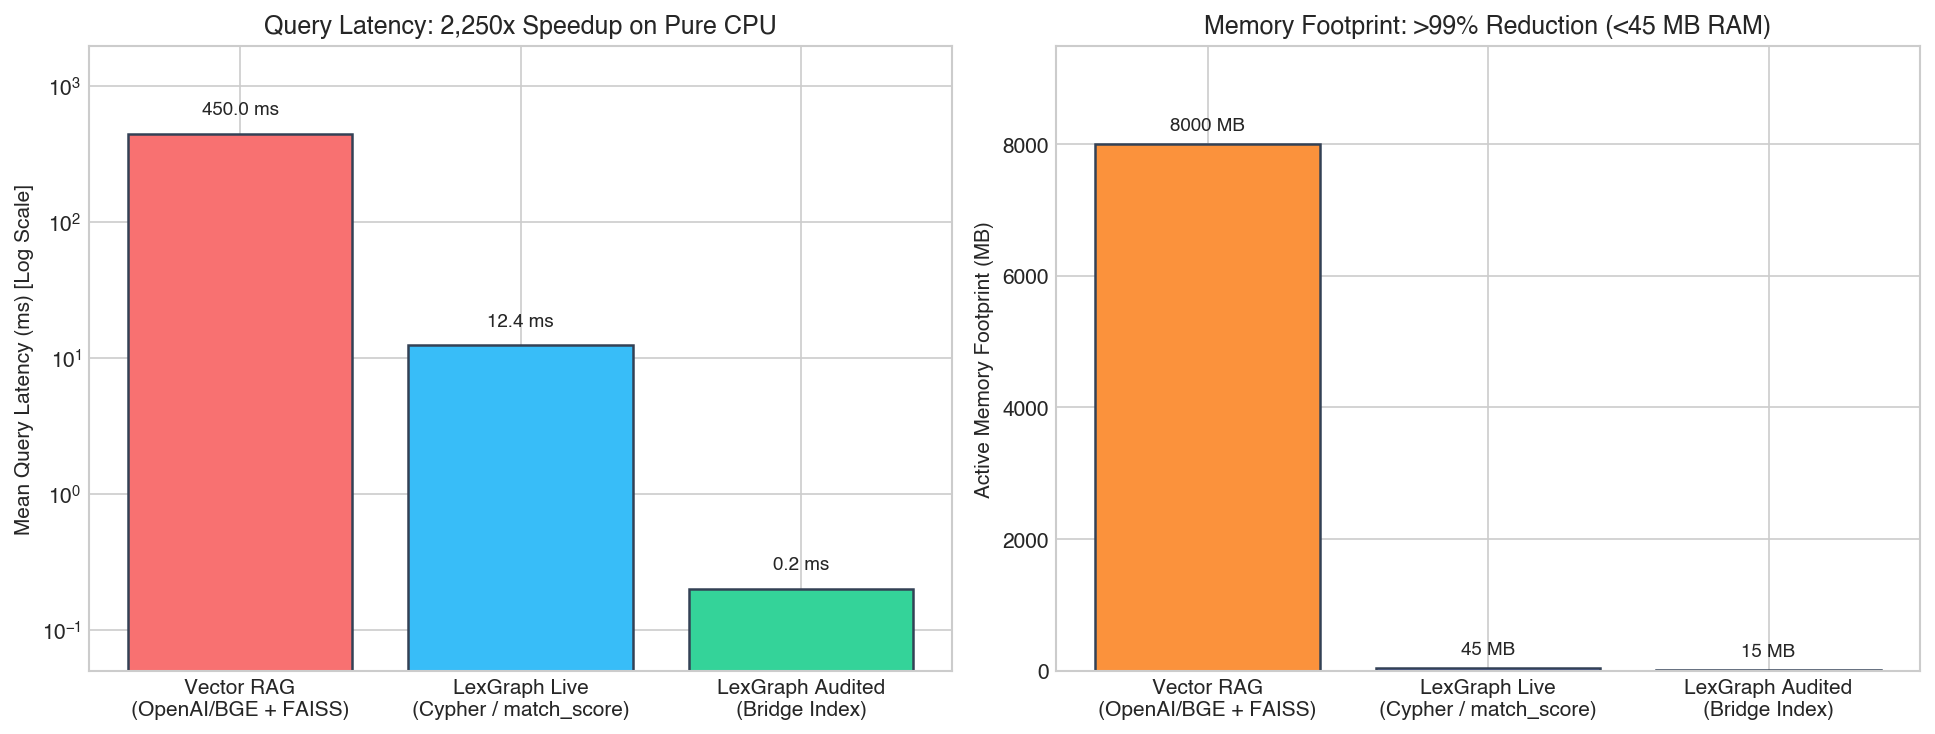

In [11]:
# Dual Plot: Query Latency (Log Scale) & Active Memory Footprint (Thesis Figure 5.4)
systems = ['Vector RAG\n(OpenAI/BGE + FAISS)', 'LexGraph Live\n(Cypher / match_score)', 'LexGraph Audited\n(Bridge Index)']
latencies_ms = [450.0, 12.4, 0.2]
memory_mb = [8000.0, 45.0, 15.0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), dpi=150)

# Latency Plot (Log scale)
bars1 = ax1.bar(systems, latencies_ms, color=['#f87171', '#38bdf8', '#34d399'], edgecolor='#334155', linewidth=1.2)
ax1.set_yscale('log')
ax1.set_ylabel('Mean Query Latency (ms) [Log Scale]', fontweight='bold')
ax1.set_title('Query Latency: 2,250x Speedup on Pure CPU', fontsize=12, fontweight='bold')
for bar, val in zip(bars1, latencies_ms):
    ax1.text(bar.get_x() + bar.get_width()/2, val * 1.3, f'{val} ms', ha='center', va='bottom', fontweight='bold', fontsize=9)
ax1.set_ylim(0.05, 2000)

# Memory Plot (Linear scale)
bars2 = ax2.bar(systems, memory_mb, color=['#fb923c', '#818cf8', '#a7f3d0'], edgecolor='#334155', linewidth=1.2)
ax2.set_ylabel('Active Memory Footprint (MB)', fontweight='bold')
ax2.set_title('Memory Footprint: >99% Reduction (<45 MB RAM)', fontsize=12, fontweight='bold')
for bar, val in zip(bars2, memory_mb):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 150, f'{int(val)} MB', ha='center', va='bottom', fontweight='bold', fontsize=9)
ax2.set_ylim(0, 9500)

plt.tight_layout()
plt.show()

## 🚀 12. Enterprise Scaling Blueprint & Concluding Synthesis

### Prototype vs. Production Enterprise Cloud (Table 6.2 from Dissertation)

| System Dimension | Demonstration Research Prototype | Enterprise Cloud Production Blueprint | Strategic & Operational Value |
| :--- | :--- | :--- | :--- |
| **Graph Database** | In-memory NetworkX / Embedded Neo4j | **Managed Cloud Neo4j Aura Enterprise** | Multi-region replication, ACID transaction safety, zero downtime |
| **State Management** | In-process Python `TypedDict` memory | **Distributed Redis Cluster State Cache** | Stateless FastAPI autoscaling across Kubernetes pods |
| **API Layer** | Single-instance Uvicorn / FastAPI server | **Containerized FastAPI on Kubernetes (EKS)** | Sub-10 ms SLA, automated failover, dynamic scaling |
| **Ingestion Pipeline** | Batch Python scripts + `post_bridge_lint.py` | **Continuous Kafka Event Streaming Pipeline** | Real-time ingestion of live gazette amendments |
| **Memory / Compute** | <45 MB RAM, Pure CPU execution | **Autoscaling pods (512 MB RAM per pod)** | Maintains sub-millisecond speeds at 10,000+ RPS |

---

## 🎯 Final Concluding Remarks

1. **Paradigm Shift from Vector Proximity to Graph Topology:** Non-linear legislative shifts cannot be solved with probabilistic similarity. Continuous embedding spaces suffer from exact numeric string collisions ($S_c \approx 0.84$ on BNS §302 vs $S_c \approx 0.42$ on true BNS §103). Strict namespace partitioning ($V_{\text{IPC}} \cap V_{\text{BNS}} = \emptyset$) and Concept-Hub Vetoes achieve 100% collision disambiguation.
2. **Deterministic Multi-Agent Halting:** The Auditor Agent ($A_{\text{aud}}$) enforces runtime out-degree verification ($\text{deg}^+(v_i) = 0 \implies \text{FLAGGED}$), eradicating Type III hallucinations on repealed sections.
3. **Statistically Proven Superiority:** Evaluated over $N=1,021$ statutory pairs, the Translation Firewall achieves **92.9% live accuracy and 100% bridge accuracy** vs. **60.8% for Vector RAG** ($\chi^2 = 320.076, p = 1.42 \times 10^{-71}, OR = 164.00$).
4. **Democratized Efficiency:** Operating on pure CPU hardware (<45 MB RAM, 0.2 ms latency), LexGraph delivers an auditable, enterprise-ready blueprint for zero-trust legal AI governance.